# Análisis descriptivo del dataset Iris

## Distribución de `PetalLengthCm`

**Dataset:** Iris Species (150 observaciones)  
**Variable analizada:** longitud del pétalo, en centímetros (`PetalLengthCm`)

Este notebook desarrolla un flujo completo de análisis descriptivo. Cada resultado contiene
su procedimiento, una visualización cuando corresponde y tres interpretaciones.
Las medidas de variabilidad se presentan como **muestrales** (`ddof=1`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Permite ejecutar el notebook desde la raíz del proyecto o desde notebooks/.
project_root = Path.cwd()
if not (project_root / "data" / "Iris.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "Iris.csv"

assert data_path.exists(), f"No se encontró el archivo: {data_path}"
print(f"Archivo utilizado: {data_path.resolve()}")

Archivo utilizado: C:\Users\ldavi\OneDrive\Documentos\workspace\Estadistica_tarea_1\data\Iris.csv


## 0. Carga y validación del conjunto de datos

In [2]:
iris = pd.read_csv(data_path)
x = iris["PetalLengthCm"].dropna().astype(float)

print(f"Observaciones: {len(iris)}")
print(f"Valores faltantes en PetalLengthCm: {iris['PetalLengthCm'].isna().sum()}")
print(f"Rango observado: [{x.min():.1f}, {x.max():.1f}] cm")
display(iris.head())
display(iris["Species"].value_counts().rename_axis("Especie").to_frame("Frecuencia"))

Observaciones: 150
Valores faltantes en PetalLengthCm: 0
Rango observado: [1.0, 6.9] cm


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1000,3.5000,1.4000,0.2000,Iris-setosa
1,2,4.9000,3.0000,1.4000,0.2000,Iris-setosa
2,3,4.7000,3.2000,1.3000,0.2000,Iris-setosa
3,4,4.6000,3.1000,1.5000,0.2000,Iris-setosa
4,5,5.0000,3.6000,1.4000,0.2000,Iris-setosa


,Frecuencia
Especie,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## 1. Tabla de distribución de frecuencias con 8 clases

Se utilizan ocho intervalos de amplitud constante de **0.75 cm**, desde 1.00 hasta
7.00 cm. El límite superior del último intervalo se incluye para mantener una
partición completa del rango de la variable.

In [3]:
n = len(x)
edges = np.linspace(1.0, 7.0, 9)
class_marks = (edges[:-1] + edges[1:]) / 2
frequencies, _ = np.histogram(x, bins=edges)
relative = frequencies / n
cumulative = np.cumsum(frequencies)
cumulative_relative = np.cumsum(relative)

labels = [
    f"[{left:.2f}, {right:.2f}{']' if i == len(edges)-2 else ')'}"
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:]))
]
frequency_table = pd.DataFrame({
    "Clase (cm)": labels,
    "Marca de clase": class_marks,
    "fᵢ": frequencies,
    "hᵢ": relative,
    "%": relative * 100,
    "Fᵢ": cumulative,
    "Hᵢ": cumulative_relative,
})
display(frequency_table)
assert frequencies.sum() == n

modal_idx = int(np.argmax(frequencies))
display(Markdown(f'''
**Interpretaciones**

1. Las {n} observaciones quedan clasificadas sin pérdida en 8 intervalos de igual amplitud (0.75 cm).
2. La clase modal es **{labels[modal_idx]} cm**, con {frequencies[modal_idx]} observaciones ({relative[modal_idx]*100:.1f}%).
3. Hasta el límite de {edges[4]:.2f} cm se acumulan {cumulative[3]} observaciones ({cumulative_relative[3]*100:.1f}%); la tabla permite ubicar la concentración de longitudes en el rango completo.
'''))

,Clase (cm),Marca de clase,fᵢ,hᵢ,%,Fᵢ,Hᵢ
0,"[1.00, 1.75)",1.3750,48,0.3200,32.0000,48,0.3200
1,"[1.75, 2.50)",2.1250,2,0.0133,1.3333,50,0.3333
2,"[2.50, 3.25)",2.8750,1,0.0067,0.6667,51,0.3400
3,"[3.25, 4.00)",3.6250,10,0.0667,6.6667,61,0.4067
4,"[4.00, 4.75)",4.3750,34,0.2267,22.6667,95,0.6333
5,"[4.75, 5.50)",5.1250,27,0.1800,18.0000,122,0.8133
6,"[5.50, 6.25)",5.8750,22,0.1467,14.6667,144,0.9600
7,"[6.25, 7.00]",6.6250,6,0.0400,4.0000,150,1.0000



**Interpretaciones**

1. Las 150 observaciones quedan clasificadas sin pérdida en 8 intervalos de igual amplitud (0.75 cm).
2. La clase modal es **[1.00, 1.75) cm**, con 48 observaciones (32.0%).
3. Hasta el límite de 4.00 cm se acumulan 61 observaciones (40.7%); la tabla permite ubicar la concentración de longitudes en el rango completo.


## 2, 3 y 4. Histograma, polígono de frecuencias y ojiva

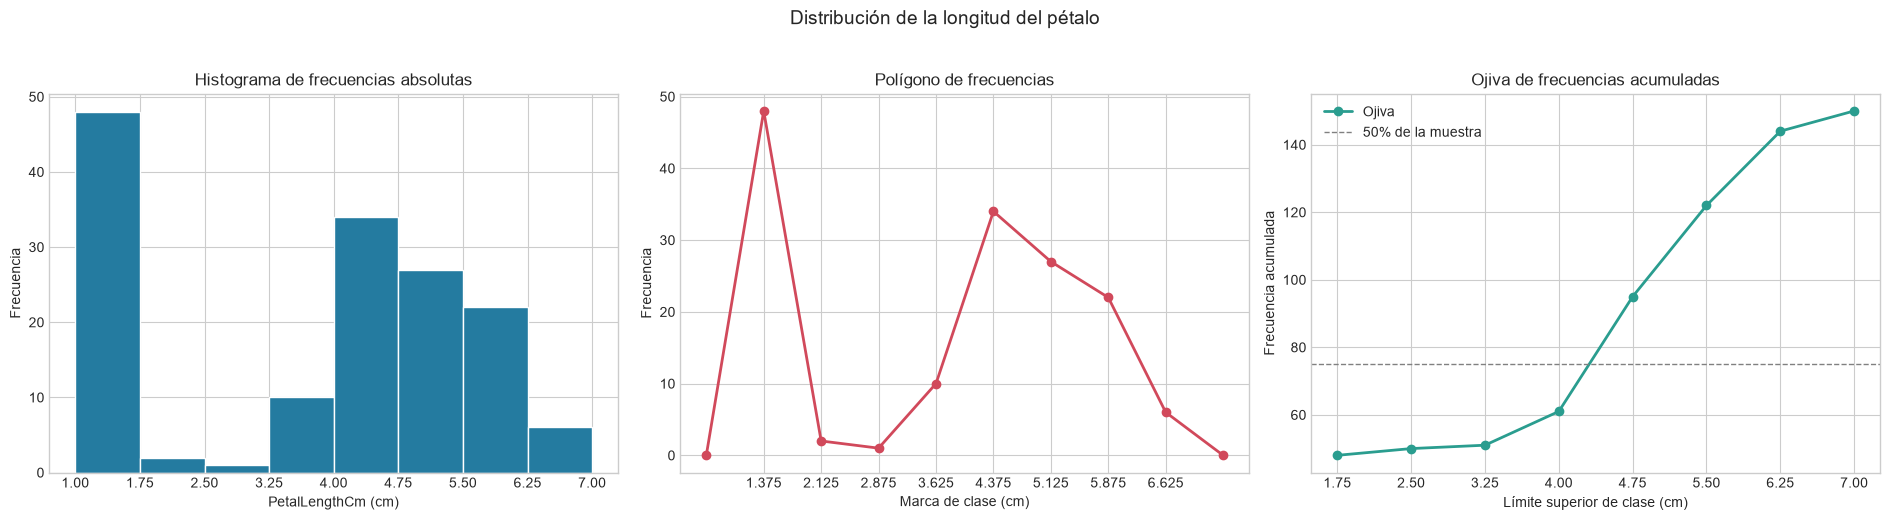


### 2. Histograma - interpretaciones

1. La barra más alta coincide con la clase **[1.00, 1.75) cm**; concentra 48 longitudes observadas.
2. El histograma muestra cómo se distribuyen las frecuencias absolutas y permite comparar visualmente la densidad de cada intervalo.
3. Hay 0 clase(s) sin observaciones, lo que evidencia separación entre zonas de valores de la variable.

### 3. Polígono de frecuencias - interpretaciones

1. El polígono confirma el máximo en la marca de clase 1.375 cm.
2. La línea permite apreciar los ascensos y descensos entre clases contiguas, sin ocultar la frecuencia exacta de cada marca de clase.
3. Los tramos bajos entre picos reflejan que la variable no se concentra de manera uniforme en todo el intervalo de 1.00 a 7.00 cm.

### 4. Ojiva - interpretaciones

1. La ojiva es no decreciente porque cada punto suma las frecuencias de las clases anteriores.
2. Al límite superior de 4.00 cm se ha acumulado el 40.7% de las observaciones.
3. La curva alcanza 150 observaciones en el límite final de 7.00 cm, comprobando que cubre la muestra completa.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].hist(x, bins=edges, edgecolor="white", color="#247BA0")
axes[0].set(title="Histograma de frecuencias absolutas", xlabel="PetalLengthCm (cm)", ylabel="Frecuencia")
axes[0].set_xticks(edges)

polygon_x = np.r_[edges[0] - (edges[1]-edges[0])/2, class_marks, edges[-1] + (edges[1]-edges[0])/2]
polygon_y = np.r_[0, frequencies, 0]
axes[1].plot(polygon_x, polygon_y, marker="o", color="#D1495B", linewidth=2)
axes[1].set(title="Polígono de frecuencias", xlabel="Marca de clase (cm)", ylabel="Frecuencia")
axes[1].set_xticks(class_marks)

axes[2].plot(edges[1:], cumulative, marker="o", color="#2A9D8F", linewidth=2, label="Ojiva")
axes[2].axhline(n/2, color="gray", linestyle="--", linewidth=1, label="50% de la muestra")
axes[2].set(title="Ojiva de frecuencias acumuladas", xlabel="Límite superior de clase (cm)", ylabel="Frecuencia acumulada")
axes[2].set_xticks(edges[1:])
axes[2].legend()

fig.suptitle("Distribución de la longitud del pétalo", y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

empty_classes = int((frequencies == 0).sum())
display(Markdown(f'''
### 2. Histograma - interpretaciones

1. La barra más alta coincide con la clase **{labels[modal_idx]} cm**; concentra {frequencies[modal_idx]} longitudes observadas.
2. El histograma muestra cómo se distribuyen las frecuencias absolutas y permite comparar visualmente la densidad de cada intervalo.
3. Hay {empty_classes} clase(s) sin observaciones, lo que evidencia separación entre zonas de valores de la variable.

### 3. Polígono de frecuencias - interpretaciones

1. El polígono confirma el máximo en la marca de clase {class_marks[modal_idx]:.3f} cm.
2. La línea permite apreciar los ascensos y descensos entre clases contiguas, sin ocultar la frecuencia exacta de cada marca de clase.
3. Los tramos bajos entre picos reflejan que la variable no se concentra de manera uniforme en todo el intervalo de 1.00 a 7.00 cm.

### 4. Ojiva - interpretaciones

1. La ojiva es no decreciente porque cada punto suma las frecuencias de las clases anteriores.
2. Al límite superior de {edges[4]:.2f} cm se ha acumulado el {cumulative_relative[3]*100:.1f}% de las observaciones.
3. La curva alcanza {n} observaciones en el límite final de {edges[-1]:.2f} cm, comprobando que cubre la muestra completa.
'''))

## 5. Medidas de tendencia central

In [5]:
arithmetic_mean = x.mean()
geometric_mean = stats.gmean(x)
harmonic_mean = stats.hmean(x)
trimmed_mean = stats.trim_mean(x, proportiontocut=0.05)
mode_result = stats.mode(x, keepdims=False)
mode_value = float(mode_result.mode)
mode_frequency = int(mode_result.count)
median = x.median()

central_table = pd.DataFrame({
    "Medida": ["Media aritmética", "Media geométrica", "Media armónica", "Media recortada al 5%", "Moda", "Mediana"],
    "Valor (cm)": [arithmetic_mean, geometric_mean, harmonic_mean, trimmed_mean, mode_value, median],
})
display(central_table)
display(Markdown(f'''
**Interpretaciones**

1. La media aritmética es **{arithmetic_mean:.4f} cm**: representa el promedio global de la longitud del pétalo.
2. La mediana es **{median:.4f} cm**; la mitad de las observaciones no supera este valor y la otra mitad no queda por debajo de él.
3. La moda es **{mode_value:.1f} cm** y aparece {mode_frequency} veces. La media recortada ({trimmed_mean:.4f} cm) se calcula eliminando aproximadamente el 5% de observaciones de cada extremo y permite contrastar la influencia de las colas.
'''))

,Medida,Valor (cm)
0,Media aritmética,3.7587
1,Media geométrica,3.2398
2,Media armónica,2.6965
3,Media recortada al 5%,3.7478
4,Moda,1.5000
5,Mediana,4.3500



**Interpretaciones**

1. La media aritmética es **3.7587 cm**: representa el promedio global de la longitud del pétalo.
2. La mediana es **4.3500 cm**; la mitad de las observaciones no supera este valor y la otra mitad no queda por debajo de él.
3. La moda es **1.5 cm** y aparece 14 veces. La media recortada (3.7478 cm) se calcula eliminando aproximadamente el 5% de observaciones de cada extremo y permite contrastar la influencia de las colas.


## 6. Medidas de dispersión

In [6]:
data_range = x.max() - x.min()
mean_absolute_deviation = (x - arithmetic_mean).abs().mean()
sample_variance = x.var(ddof=1)
sample_std = x.std(ddof=1)
coefficient_variation = sample_std / arithmetic_mean * 100

dispersion_table = pd.DataFrame({
    "Medida": ["Rango", "Desviación absoluta media", "Varianza muestral", "Desviación estándar muestral", "Coeficiente de variación"],
    "Valor": [data_range, mean_absolute_deviation, sample_variance, sample_std, coefficient_variation],
    "Unidad": ["cm", "cm", "cm²", "cm", "%"],
})
display(dispersion_table)
display(Markdown(f'''
**Interpretaciones**

1. El rango es **{data_range:.4f} cm** ({x.min():.1f} a {x.max():.1f} cm), por lo que la amplitud total de los datos es amplia.
2. La desviación estándar muestral es **{sample_std:.4f} cm**; una longitud típica se aleja de la media en aproximadamente esa magnitud.
3. El coeficiente de variación es **{coefficient_variation:.2f}%**, lo que cuantifica una dispersión relativa considerable respecto a la media; no es una variable homogénea en una sola escala estrecha.
'''))

,Medida,Valor,Unidad
0,Rango,5.9000,cm
1,Desviación absoluta media,1.5619,cm
2,Varianza muestral,3.1132,cm²
3,Desviación estándar muestral,1.7644,cm
4,Coeficiente de variación,46.9427,%



**Interpretaciones**

1. El rango es **5.9000 cm** (1.0 a 6.9 cm), por lo que la amplitud total de los datos es amplia.
2. La desviación estándar muestral es **1.7644 cm**; una longitud típica se aleja de la media en aproximadamente esa magnitud.
3. El coeficiente de variación es **46.94%**, lo que cuantifica una dispersión relativa considerable respecto a la media; no es una variable homogénea en una sola escala estrecha.


## 7. Sesgo y curtosis

In [7]:
skewness = stats.skew(x, bias=False)
excess_kurtosis = stats.kurtosis(x, fisher=True, bias=False)
pearson_kurtosis = excess_kurtosis + 3

shape_table = pd.DataFrame({
    "Medida": ["Sesgo (Fisher-Pearson)", "Exceso de curtosis (Fisher)", "Curtosis de Pearson"],
    "Valor": [skewness, excess_kurtosis, pearson_kurtosis],
})
display(shape_table)

skew_description = "ligeramente asimétrica a la derecha" if skewness > 0 else "ligeramente asimétrica a la izquierda"
kurt_description = "leptocúrtica" if excess_kurtosis > 0 else "platicúrtica"
display(Markdown(f'''
**Interpretaciones**

1. El sesgo es **{skewness:.4f}**; por ser negativo, la distribución es {skew_description}.
2. El exceso de curtosis es **{excess_kurtosis:.4f}**. Frente a la normal (exceso igual a 0), la distribución es {kurt_description}.
3. La curtosis de Pearson es **{pearson_kurtosis:.4f}**; reportar ambas convenciones evita confundir la curtosis total con el exceso de curtosis.
'''))

,Medida,Valor
0,Sesgo (Fisher-Pearson),-0.2745
1,Exceso de curtosis (Fisher),-1.4019
2,Curtosis de Pearson,1.5981



**Interpretaciones**

1. El sesgo es **-0.2745**; por ser negativo, la distribución es ligeramente asimétrica a la izquierda.
2. El exceso de curtosis es **-1.4019**. Frente a la normal (exceso igual a 0), la distribución es platicúrtica.
3. La curtosis de Pearson es **1.5981**; reportar ambas convenciones evita confundir la curtosis total con el exceso de curtosis.


## 8. Cuartiles, deciles, valores atípicos y diagrama de caja y bigote

,Medida,Valor (cm)
0,Q1 (P25),1.6000
1,Q2 / mediana (P50),4.3500
2,Q3 (P75),5.1000
3,RIC,3.5000
4,Límite inferior de Tukey,-3.6500
5,Límite superior de Tukey,10.3500


,Decil,Valor (cm)
0,D1,1.4000
1,D2,1.5000
2,D3,1.7000
3,D4,3.9000
4,D5,4.3500
5,D6,4.6400
6,D7,5.0000
7,D8,5.3200
8,D9,5.8000


Valores atípicos con la regla 1.5 × RIC: No se detectaron valores atípicos


C:\Users\ldavi\AppData\Local\Temp\ipykernel_21844\3083707583.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(x, vert=False, patch_artist=True, boxprops=dict(facecolor="#9AD1D4"), medianprops=dict(color="#D1495B", linewidth=2))


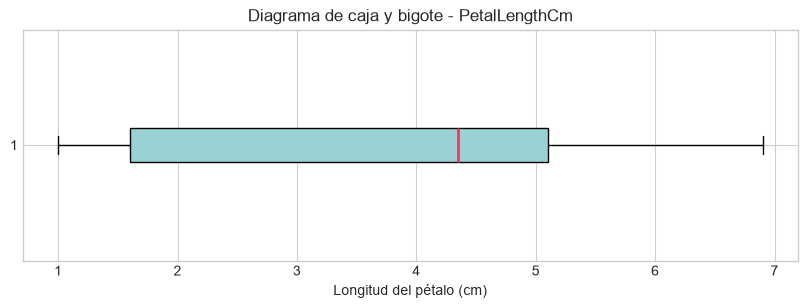


**Interpretaciones**

1. El 25% de las longitudes es menor o igual que **1.6000 cm** (Q1), mientras que el 75% es menor o igual que **5.1000 cm** (Q3).
2. El rango intercuartílico es **3.5000 cm**; resume la amplitud de la mitad central de los datos y es resistente a valores extremos.
3. No se detectaron valores atípicos mediante los límites de Tukey [-3.6500, 10.3500] cm; el diagrama de caja permite verificar visualmente esa conclusión.


In [8]:
q1, q2, q3 = np.percentile(x, [25, 50, 75], method="linear")
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = x[(x < lower_fence) | (x > upper_fence)].sort_values().to_list()
deciles = np.percentile(x, np.arange(10, 100, 10), method="linear")

position_table = pd.DataFrame({
    "Medida": ["Q1 (P25)", "Q2 / mediana (P50)", "Q3 (P75)", "RIC", "Límite inferior de Tukey", "Límite superior de Tukey"],
    "Valor (cm)": [q1, q2, q3, iqr, lower_fence, upper_fence],
})
display(position_table)
display(pd.DataFrame({"Decil": [f"D{i}" for i in range(1, 10)], "Valor (cm)": deciles}))
print("Valores atípicos con la regla 1.5 × RIC:", outliers if outliers else "No se detectaron valores atípicos")

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(x, vert=False, patch_artist=True, boxprops=dict(facecolor="#9AD1D4"), medianprops=dict(color="#D1495B", linewidth=2))
ax.set(title="Diagrama de caja y bigote - PetalLengthCm", xlabel="Longitud del pétalo (cm)")
plt.show()

outlier_text = "No se detectaron valores atípicos" if not outliers else f"Se detectaron {len(outliers)} valor(es) atípico(s): {outliers}"
display(Markdown(f'''
**Interpretaciones**

1. El 25% de las longitudes es menor o igual que **{q1:.4f} cm** (Q1), mientras que el 75% es menor o igual que **{q3:.4f} cm** (Q3).
2. El rango intercuartílico es **{iqr:.4f} cm**; resume la amplitud de la mitad central de los datos y es resistente a valores extremos.
3. {outlier_text} mediante los límites de Tukey [{lower_fence:.4f}, {upper_fence:.4f}] cm; el diagrama de caja permite verificar visualmente esa conclusión.
'''))

## Síntesis del análisis

El análisis describe la variable `PetalLengthCm` mediante tablas, gráficas, medidas
de centro, dispersión, forma y posición. Antes de integrarlo al reporte final,
conviene conservar estas salidas, enlazar este notebook desde el documento y
citar cada figura y tabla con su número correspondiente.